# Rolex Watch Price Analysis - Part 2: Database Storage
## PostgreSQL Database Setup and SQL Queries

## Libraries and settings

In [38]:
import os
import pandas as pd
import numpy as np
import psycopg2
from sqlalchemy import create_engine, text
from sqlalchemy.exc import SQLAlchemyError
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print(os.getcwd())

/Users/adisaljusi/repos/data_analytics/final


## 1. Database Setup

### Starting the PostgreSQL Database

Before running this notebook, start the PostgreSQL database using Docker Compose:

```bash
docker-compose up -d
```

This will start:
- **PostgreSQL** database on port 5432
- **pgAdmin** web interface on port 5050 (optional)

To stop the database:
```bash
docker-compose down
```

### Database Connection Details:
- **Host**: localhost
- **Port**: 5432
- **Database**: rolex_db
- **User**: rolex_user
- **Password**: rolex_password

## 2. Load Cleaned Data

In [39]:
df = pd.read_csv('rolex_data_cleaned.csv', encoding='utf-8')

print(f"Loaded dataset shape: {df.shape}")
print(f"\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

Loaded dataset shape: (2373, 19)

Column names:
 1. web_scraper_order
 2. brand_raw
 3. model_raw
 4. reference_number_raw
 5. movement_type
 6. condition_category
 7. seller_type
 8. case_material_clean
 9. bracelet_material_clean
10. material_category
11. country
12. city
13. price
14. year
15. age
16. has_box
17. has_papers
18. has_complete_set
19. is_professional


In [40]:
df.head()

,web_scraper_order,brand_raw,model_raw,reference_number_raw,movement_type,condition_category,seller_type,case_material_clean,bracelet_material_clean,material_category,country,city,price,year,age,has_box,has_papers,has_complete_set,is_professional
0,1766787541-2,Rolex,Datejust 31,278274,Automatic,New,Professional dealer,Steel,Steel,Steel,Netherlands,Franeker,11415.0,2023.0,1.0,1,1,1,1
1,1766787544-3,Rolex,Cellini Danaos,4233,Manual,Fair,Professional dealer,Rose gold,Unknown,Rose Gold,United States of America,New York City,5248.0,2010.0,14.0,1,1,1,1
2,1766787546-4,Rolex,GMT-Master II,126720VTNR,Automatic,Very Good,Partner Certified Included,Steel,Steel,Steel,Netherlands,Franeker,14745.0,2024.0,0.0,1,1,1,0
3,1766787548-5,Rolex,Sea-Dweller,1665\n \n ...,Automatic,Very Good,Professional dealer,Steel,Steel,Steel,United States of America,Colorado,23009.0,1979.0,45.0,1,1,1,1
4,1766787550-6,Rolex,Explorer,124270\n \n ...,Automatic,Very Good,Partner Certified Included,Steel,Steel,Steel,Netherlands,Franeker,7132.0,2022.0,2.0,1,1,1,0


## 3. Connect to PostgreSQL Database

In [41]:
db_config = {
    'host': 'localhost',
    'port': 5432,
    'database': 'rolex_db',
    'user': 'rolex_user',
    'password': 'rolex_password'
}

connection_string = f"postgresql://{db_config['user']}:{db_config['password']}@{db_config['host']}:{db_config['port']}/{db_config['database']}"

try:
    engine = create_engine(connection_string)
    with engine.connect() as conn:
        result = conn.execute(text("SELECT version();"))
        version = result.fetchone()[0]
        print("✓ Successfully connected to PostgreSQL!")
        print(f"\nDatabase version:")
        print(version)
except Exception as e:
    print(f"✗ Error connecting to database: {e}")
    print("\nMake sure PostgreSQL is running:")
    print("  docker-compose up -d")

✓ Successfully connected to PostgreSQL!

Database version:
PostgreSQL 15.15 on aarch64-unknown-linux-musl, compiled by gcc (Alpine 15.2.0) 15.2.0, 64-bit


## 4. Create Database Tables

### Drop existing table if it exists

In [42]:
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS watches CASCADE;"))
    conn.commit()
    print("✓ Dropped existing 'watches' table (if it existed)")

✓ Dropped existing 'watches' table (if it existed)


### Create watches table

In [43]:
create_table_sql = """
CREATE TABLE watches (
    id SERIAL PRIMARY KEY,
    web_scraper_order VARCHAR(50),
    brand VARCHAR(100),
    model VARCHAR(200),
    reference_number VARCHAR(100),
    movement_type VARCHAR(50),
    condition_category VARCHAR(50),
    seller_type VARCHAR(100),
    case_material VARCHAR(100),
    bracelet_material VARCHAR(100),
    material_category VARCHAR(50),
    country VARCHAR(100),
    city VARCHAR(100),
    price DECIMAL(12, 2),
    year INTEGER,
    age INTEGER,
    has_box INTEGER,
    has_papers INTEGER,
    has_complete_set INTEGER,
    is_professional INTEGER,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);
"""

with engine.connect() as conn:
    conn.execute(text(create_table_sql))
    conn.commit()
    print("✓ Created 'watches' table successfully")

✓ Created 'watches' table successfully


### Create indexes for better query performance

In [44]:
indexes_sql = [
    "CREATE INDEX idx_price ON watches(price);",
    "CREATE INDEX idx_country ON watches(country);",
    "CREATE INDEX idx_condition ON watches(condition_category);",
    "CREATE INDEX idx_material ON watches(material_category);",
    "CREATE INDEX idx_year ON watches(year);"
]

with engine.connect() as conn:
    for idx_sql in indexes_sql:
        conn.execute(text(idx_sql))
    conn.commit()
    print(f"✓ Created {len(indexes_sql)} indexes for performance optimization")

✓ Created 5 indexes for performance optimization


## 5. Load Data into PostgreSQL

In [45]:
df_to_db = df.rename(columns={
    'brand_raw': 'brand',
    'model_raw': 'model',
    'reference_number_raw': 'reference_number',
    'case_material_clean': 'case_material',
    'bracelet_material_clean': 'bracelet_material'
})

print(f"Loading {len(df_to_db):,} records into PostgreSQL...")

try:
    df_to_db.to_sql(
        name='watches',
        con=engine,
        if_exists='append',
        index=False,
        method='multi',
        chunksize=1000
    )
    print(f"✓ Successfully loaded {len(df_to_db):,} records into database")
except Exception as e:
    print(f"✗ Error loading data: {e}")

Loading 2,373 records into PostgreSQL...
✓ Successfully loaded 2,373 records into database


### Verify data was loaded

In [46]:
with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM watches;"))
    count = result.fetchone()[0]
    print(f"Total records in database: {count:,}")

Total records in database: 2,373


## 6. SQL Queries and Analysis

### 6.1 Basic Statistics

In [47]:
query = """
SELECT 
    COUNT(*) as total_watches,
    ROUND(AVG(price)::numeric, 2) as avg_price,
    ROUND(MIN(price)::numeric, 2) as min_price,
    ROUND(MAX(price)::numeric, 2) as max_price,
    ROUND(STDDEV(price)::numeric, 2) as std_price,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY price) as median_price
FROM watches;
"""

df_stats = pd.read_sql_query(query, engine)
print("Overall Price Statistics:")
df_stats

Overall Price Statistics:


,total_watches,avg_price,min_price,max_price,std_price,median_price
0,2373,13985.74,1294.0,205626.0,13679.3,10559.0


### 6.2 Average Price by Condition

In [48]:
query = """
SELECT 
    condition_category,
    COUNT(*) as count,
    ROUND(AVG(price)::numeric, 2) as avg_price,
    ROUND(MIN(price)::numeric, 2) as min_price,
    ROUND(MAX(price)::numeric, 2) as max_price
FROM watches
GROUP BY condition_category
ORDER BY avg_price DESC;
"""

df_condition = pd.read_sql_query(query, engine)
print("Price Statistics by Condition:")
df_condition

Price Statistics by Condition:


,condition_category,count,avg_price,min_price,max_price
0,New,345,17768.77,4296.0,205626.0
1,Unknown,162,14104.46,2808.0,102532.0
2,Very Good,1250,13925.00,2244.0,179824.0
3,Good,497,12719.95,1294.0,104954.0
4,Fair,119,8781.09,1449.0,37945.0


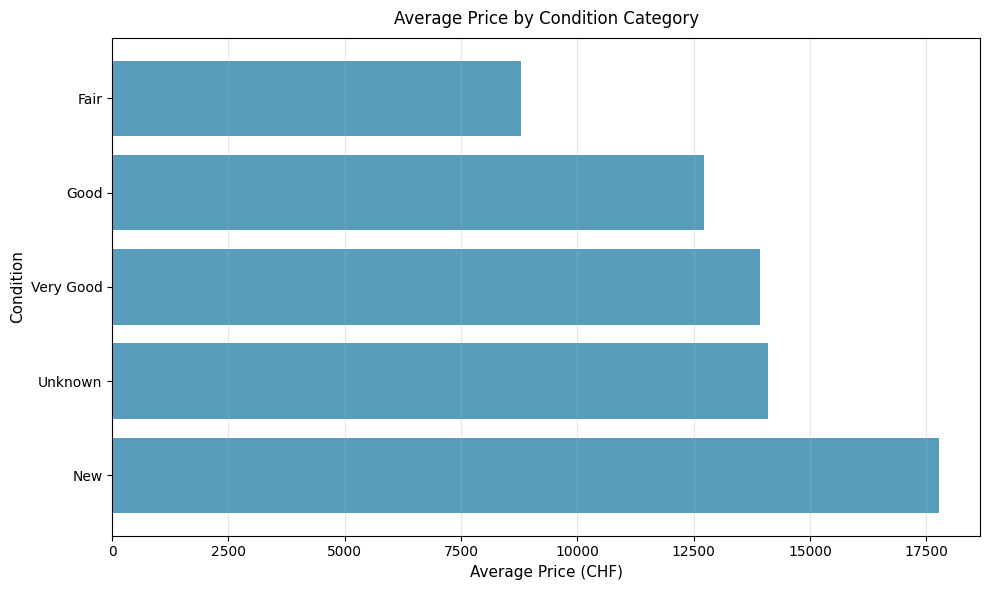

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_condition['condition_category'], df_condition['avg_price'], 
        color='#2E86AB', alpha=0.8)
ax.set_xlabel('Average Price (CHF)', fontsize=11)
ax.set_ylabel('Condition', fontsize=11)
ax.set_title('Average Price by Condition Category', fontsize=12, pad=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 Average Price by Material Category

In [50]:
query = """
SELECT 
    material_category,
    COUNT(*) as count,
    ROUND(AVG(price)::numeric, 2) as avg_price,
    ROUND(MIN(price)::numeric, 2) as min_price,
    ROUND(MAX(price)::numeric, 2) as max_price
FROM watches
WHERE material_category != 'Unknown'
GROUP BY material_category
HAVING COUNT(*) >= 10
ORDER BY avg_price DESC;
"""

df_material = pd.read_sql_query(query, engine)
print("Price Statistics by Material Category:")
df_material

Price Statistics by Material Category:


,material_category,count,avg_price,min_price,max_price
0,Platinum,14,51117.21,9885.0,111009.0
1,White Gold,75,35112.07,4198.0,179824.0
2,Rose Gold,85,33058.55,4658.0,205626.0
3,Yellow Gold,194,24757.38,2443.0,128367.0
4,Other,249,15973.35,1343.0,89213.0
5,Gold/Steel,302,10675.27,2433.0,23137.0
6,Steel,1454,10333.50,1294.0,87548.0


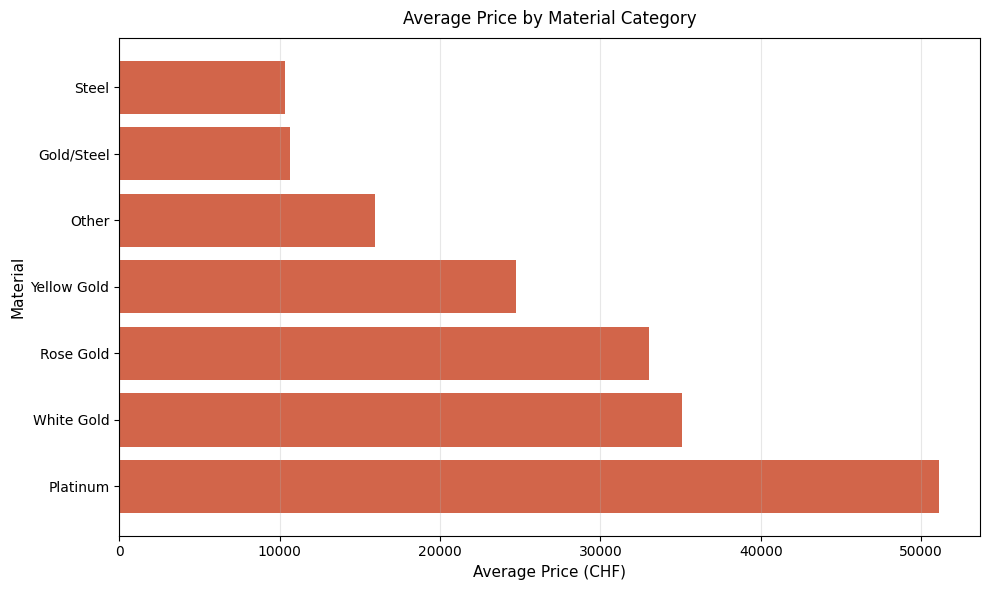

In [51]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_material['material_category'], df_material['avg_price'], 
        color='#C73E1D', alpha=0.8)
ax.set_xlabel('Average Price (CHF)', fontsize=11)
ax.set_ylabel('Material', fontsize=11)
ax.set_title('Average Price by Material Category', fontsize=12, pad=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4 Top 10 Countries by Number of Listings

In [52]:
query = """
SELECT 
    country,
    COUNT(*) as num_listings,
    ROUND(AVG(price)::numeric, 2) as avg_price,
    ROUND((COUNT(*) * 100.0 / (SELECT COUNT(*) FROM watches))::numeric, 2) as percentage
FROM watches
WHERE country != 'Unknown'
GROUP BY country
ORDER BY num_listings DESC
LIMIT 10;
"""

df_countries = pd.read_sql_query(query, engine)
print("Top 10 Countries by Number of Listings:")
df_countries

Top 10 Countries by Number of Listings:


,country,num_listings,avg_price,percentage
0,United States of America,935,14502.62,39.40
1,Japan,758,11803.11,31.94
2,Italy,96,16292.36,4.05
3,Germany,96,15186.82,4.05
4,Netherlands,94,12911.65,3.96
5,United Kingdom,87,16074.34,3.67
6,Hong Kong,78,17582.01,3.29
7,France,37,16316.59,1.56
8,Spain,36,16732.86,1.52
9,Belgium,24,14444.83,1.01


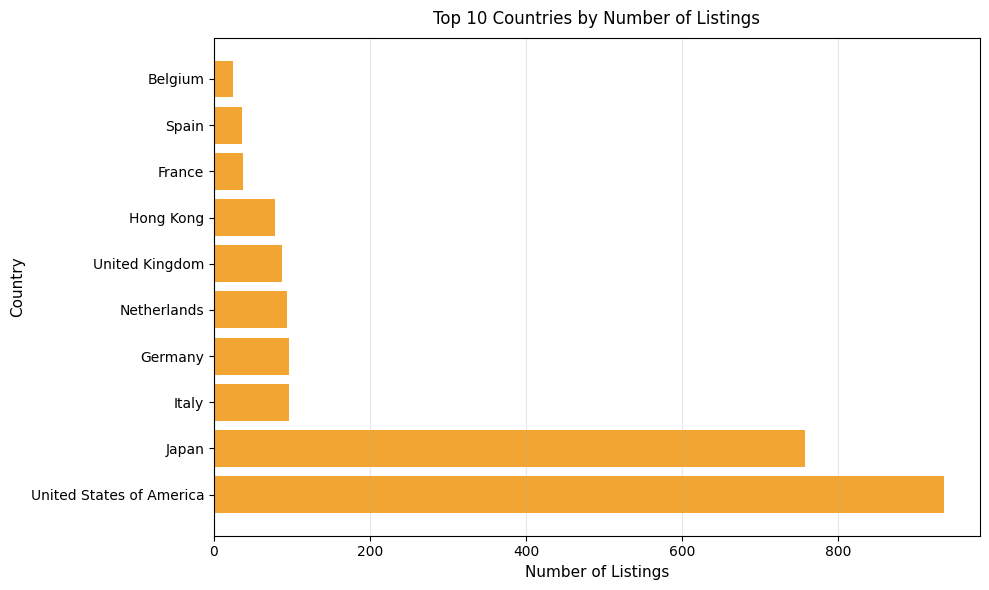

In [53]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_countries['country'], df_countries['num_listings'], 
        color='#F18F01', alpha=0.8)
ax.set_xlabel('Number of Listings', fontsize=11)
ax.set_ylabel('Country', fontsize=11)
ax.set_title('Top 10 Countries by Number of Listings', fontsize=12, pad=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.5 Impact of Documentation on Price

In [54]:
query = """
SELECT 
    CASE 
        WHEN has_complete_set = 1 THEN 'Complete Set (Box + Papers)'
        WHEN has_box = 1 AND has_papers = 0 THEN 'Box Only'
        WHEN has_box = 0 AND has_papers = 1 THEN 'Papers Only'
        ELSE 'No Documentation'
    END as documentation,
    COUNT(*) as count,
    ROUND(AVG(price)::numeric, 2) as avg_price,
    ROUND(MIN(price)::numeric, 2) as min_price,
    ROUND(MAX(price)::numeric, 2) as max_price
FROM watches
GROUP BY 
    CASE 
        WHEN has_complete_set = 1 THEN 'Complete Set (Box + Papers)'
        WHEN has_box = 1 AND has_papers = 0 THEN 'Box Only'
        WHEN has_box = 0 AND has_papers = 1 THEN 'Papers Only'
        ELSE 'No Documentation'
    END
ORDER BY avg_price DESC;
"""

df_docs = pd.read_sql_query(query, engine)
print("Price Statistics by Documentation:")
df_docs

Price Statistics by Documentation:


,documentation,count,avg_price,min_price,max_price
0,Complete Set (Box + Papers),2373,13985.74,1294.0,205626.0


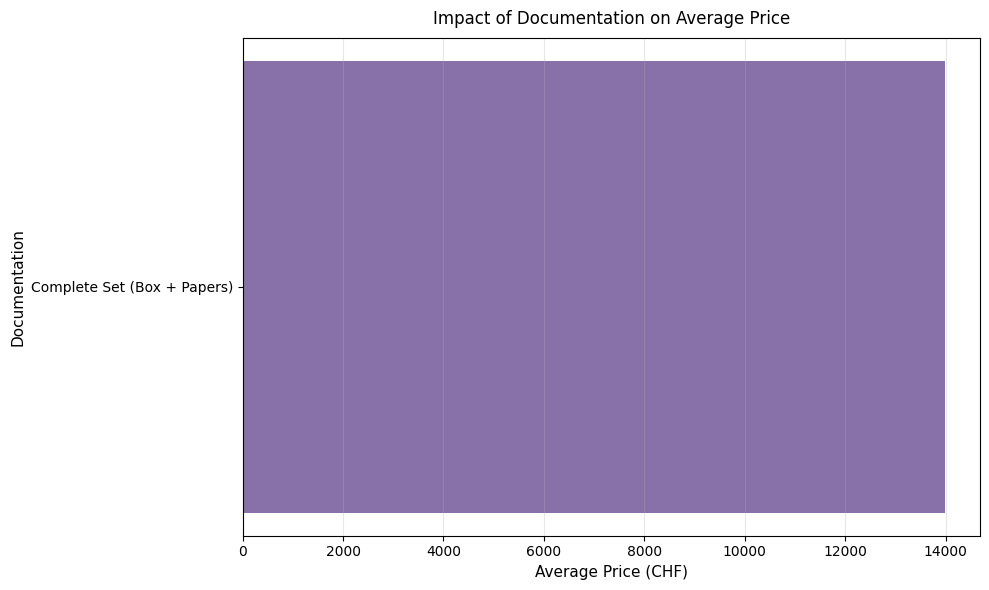

In [55]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_docs['documentation'], df_docs['avg_price'], 
        color='#6A4C93', alpha=0.8)
ax.set_xlabel('Average Price (CHF)', fontsize=11)
ax.set_ylabel('Documentation', fontsize=11)
ax.set_title('Impact of Documentation on Average Price', fontsize=12, pad=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.6 Professional Dealers vs Private Sellers

In [56]:
query = """
SELECT 
    seller_type,
    COUNT(*) as count,
    ROUND(AVG(price)::numeric, 2) as avg_price,
    ROUND(STDDEV(price)::numeric, 2) as std_price,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY price) as median_price
FROM watches
GROUP BY seller_type
ORDER BY avg_price DESC;
"""

df_sellers = pd.read_sql_query(query, engine)
print("Price Statistics by Seller Type:")
df_sellers

Price Statistics by Seller Type:


,seller_type,count,avg_price,std_price,median_price
0,Private Seller,76,17687.18,12295.41,14274.0
1,Professional dealer,1603,14760.85,14604.13,11181.0
2,Partner Certified Included,694,11790.04,11107.00,8789.5


### 6.7 Price Distribution by Age Groups

In [57]:
query = """
SELECT 
    CASE 
        WHEN age < 5 THEN '0-4 years (Modern)'
        WHEN age >= 5 AND age < 15 THEN '5-14 years (Recent)'
        WHEN age >= 15 AND age < 25 THEN '15-24 years (Pre-owned)'
        WHEN age >= 25 AND age < 40 THEN '25-39 years (Vintage)'
        WHEN age >= 40 THEN '40+ years (Antique)'
        ELSE 'Unknown'
    END as age_group,
    COUNT(*) as count,
    ROUND(AVG(price)::numeric, 2) as avg_price,
    ROUND(MIN(price)::numeric, 2) as min_price,
    ROUND(MAX(price)::numeric, 2) as max_price
FROM watches
WHERE age IS NOT NULL
GROUP BY 
    CASE 
        WHEN age < 5 THEN '0-4 years (Modern)'
        WHEN age >= 5 AND age < 15 THEN '5-14 years (Recent)'
        WHEN age >= 15 AND age < 25 THEN '15-24 years (Pre-owned)'
        WHEN age >= 25 AND age < 40 THEN '25-39 years (Vintage)'
        WHEN age >= 40 THEN '40+ years (Antique)'
        ELSE 'Unknown'
    END
ORDER BY avg_price DESC;
"""

df_age_groups = pd.read_sql_query(query, engine)
print("Price Statistics by Age Group:")
df_age_groups

Price Statistics by Age Group:


,age_group,count,avg_price,min_price,max_price
0,0-4 years (Modern),434,17104.02,5244.0,179824.0
1,5-14 years (Recent),295,14370.70,4068.0,89213.0
2,15-24 years (Pre-owned),194,10997.61,2244.0,152162.0
3,40+ years (Antique),94,9574.23,1449.0,87548.0
4,25-39 years (Vintage),157,7911.83,2537.0,54942.0


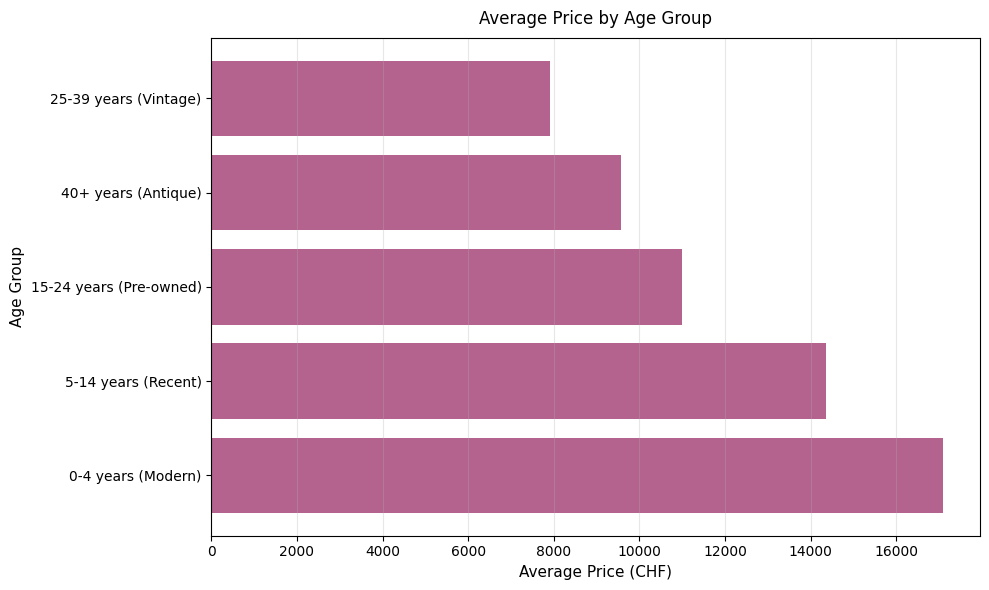

In [58]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_age_groups['age_group'], df_age_groups['avg_price'], 
        color='#A23B72', alpha=0.8)
ax.set_xlabel('Average Price (CHF)', fontsize=11)
ax.set_ylabel('Age Group', fontsize=11)
ax.set_title('Average Price by Age Group', fontsize=12, pad=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.8 Most Expensive Watches

In [59]:
query = """
SELECT 
    model,
    reference_number,
    material_category,
    condition_category,
    year,
    country,
    price,
    seller_type
FROM watches
ORDER BY price DESC
LIMIT 10;
"""

df_expensive = pd.read_sql_query(query, engine)
print("Top 10 Most Expensive Watches:")
df_expensive

Top 10 Most Expensive Watches:


,model,reference_number,material_category,condition_category,year,country,price,seller_type
0,Daytona,126525LN\n \n ...,Rose Gold,New,NaN,United States of America,205626.0,Professional dealer
1,Daytona,126529LN,White Gold,Very Good,2024.0,United Kingdom,179824.0,Professional dealer
2,Daytona,116589BR,White Gold,Very Good,2009.0,Italy,152162.0,Professional dealer
3,GMT-Master II,116758SARU\n \n ...,Yellow Gold,Very Good,NaN,United States of America,128367.0,Partner Certified Included
4,Day-Date 40,228396TBR METEORITE BAGUETTE,Platinum,Very Good,NaN,United States of America,111009.0,Professional dealer
5,Daytona,116599SA,White Gold,Good,NaN,United States of America,104954.0,Professional dealer
6,Yacht-Master 40,116695SATS,Rose Gold,Unknown,NaN,United States of America,102532.0,Professional dealer
7,Yacht-Master 40,116695 SATS,Rose Gold,Good,2020.0,Japan,95079.0,Professional dealer
8,Daytona,126506,Platinum,Very Good,2024.0,Japan,94535.0,Partner Certified Included
9,Lady-Datejust,279458RBR,Yellow Gold,Very Good,NaN,Hong Kong,89290.0,Professional dealer


### 6.9 Most Common Models

In [60]:
query = """
SELECT 
    model,
    COUNT(*) as count,
    ROUND(AVG(price)::numeric, 2) as avg_price,
    ROUND(MIN(price)::numeric, 2) as min_price,
    ROUND(MAX(price)::numeric, 2) as max_price
FROM watches
WHERE model IS NOT NULL AND model != 'None'
GROUP BY model
ORDER BY count DESC
LIMIT 15;
"""

df_models = pd.read_sql_query(query, engine)
print("Top 15 Most Common Models:")
df_models

Top 15 Most Common Models:


,model,count,avg_price,min_price,max_price
0,Datejust 36,362,9006.17,2588.0,20987.0
1,Lady-Datejust,230,7450.21,2921.0,89290.0
2,Submariner Date,213,12975.43,6297.0,50730.0
3,GMT-Master II,197,17922.87,8249.0,128367.0
4,Daytona,181,36780.33,12998.0,205626.0
5,Datejust 41,180,12386.96,6539.0,17761.0
6,Day-Date 36,89,25902.36,9083.0,86385.0
7,Datejust 31,88,11323.25,3986.0,34187.0
8,Explorer,65,6790.75,4662.0,11299.0
9,Explorer II,55,8234.62,5477.0,24893.0


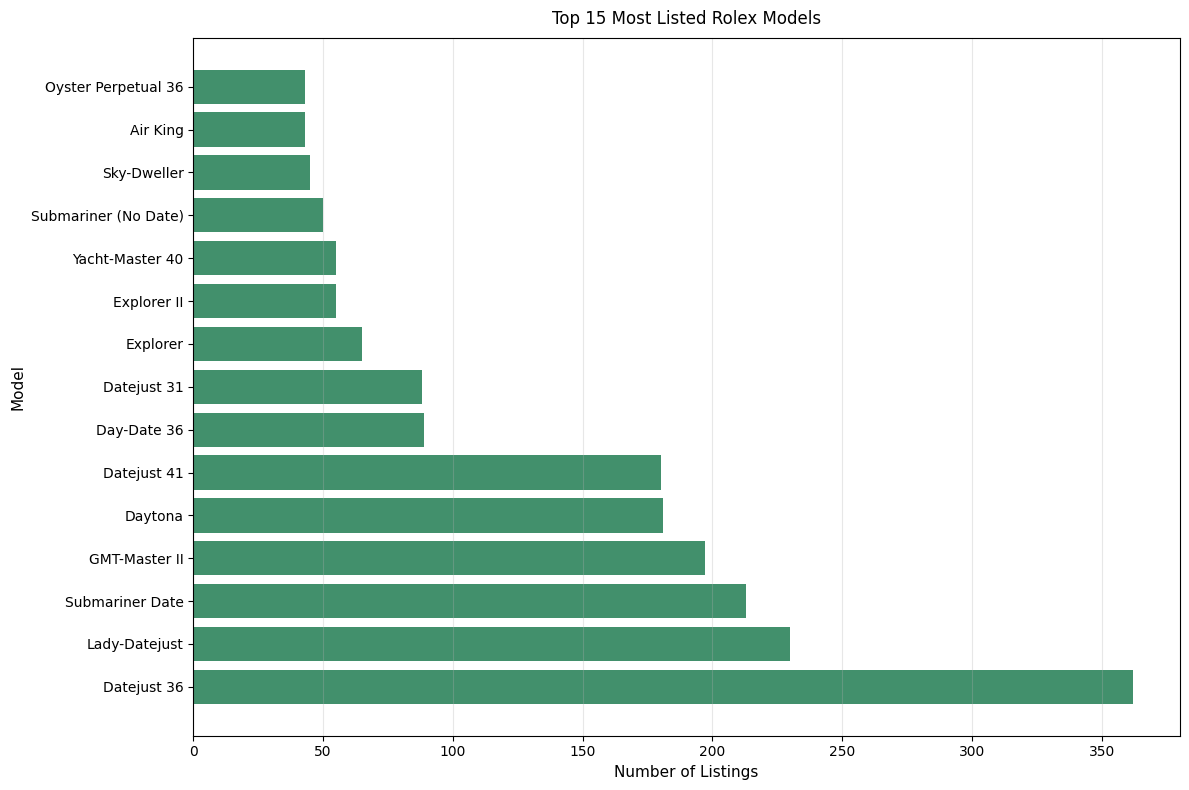

In [61]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(df_models['model'], df_models['count'], 
        color='#137547', alpha=0.8)
ax.set_xlabel('Number of Listings', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
ax.set_title('Top 15 Most Listed Rolex Models', fontsize=12, pad=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.10 Complex Query: Best Value Watches

In [62]:
query = """
WITH avg_prices AS (
    SELECT 
        material_category,
        AVG(price) as avg_mat_price
    FROM watches
    WHERE material_category != 'Unknown'
    GROUP BY material_category
)
SELECT 
    w.model,
    w.reference_number,
    w.material_category,
    w.condition_category,
    w.year,
    w.country,
    w.price,
    ROUND(ap.avg_mat_price::numeric, 2) as avg_category_price,
    ROUND(((w.price - ap.avg_mat_price) / ap.avg_mat_price * 100)::numeric, 2) as price_deviation_pct
FROM watches w
JOIN avg_prices ap ON w.material_category = ap.material_category
WHERE w.condition_category IN ('New', 'Very Good', 'Good')
    AND w.has_complete_set = 1
    AND w.material_category IN ('Steel', 'Gold/Steel')
ORDER BY price_deviation_pct ASC
LIMIT 20;
"""

df_value = pd.read_sql_query(query, engine)
print("Top 20 Best Value Watches (Below Average Price for Material):")
df_value

Top 20 Best Value Watches (Below Average Price for Material):


,model,reference_number,material_category,condition_category,year,country,price,avg_category_price,price_deviation_pct
0,Oyster,6244\n \n ...,Steel,Good,NaN,Japan,1294.0,10333.50,-87.48
1,Oysterdate Precision,6694,Steel,Good,NaN,Japan,1457.0,10333.50,-85.90
2,Oyster Perpetual Lady Date,6516,Steel,Good,NaN,Japan,1728.0,10333.50,-83.28
3,Oyster Precision,6426,Steel,Good,1962.0,Japan,1967.0,10333.50,-80.96
4,Oyster Precision,6426,Steel,Good,NaN,Japan,2035.0,10333.50,-80.31
5,Oyster Perpetual Lady Date,6919,Steel,Good,NaN,Japan,2179.0,10333.50,-78.91
6,Oyster Perpetual 26,67230,Steel,Good,NaN,Japan,2216.0,10333.50,-78.56
7,Oyster Perpetual 26,76080,Steel,Very Good,2005.0,United States of America,2244.0,10333.50,-78.28
8,Oysterdate Precision,6494,Steel,Good,1956.0,Japan,2273.0,10333.50,-78.00
9,Oyster Perpetual 34,6284\n \n ...,Steel,Good,NaN,Japan,2331.0,10333.50,-77.44


## 7. Save Query Results for Further Analysis

In [63]:
query = "SELECT * FROM watches;"
df_from_db = pd.read_sql_query(query, engine)

print(f"Retrieved {len(df_from_db):,} records from database")
print(f"\nFirst few records:")
df_from_db.head()

Retrieved 2,373 records from database

First few records:


,id,web_scraper_order,brand,model,reference_number,movement_type,condition_category,seller_type,case_material,bracelet_material,material_category,country,city,price,year,age,has_box,has_papers,has_complete_set,is_professional,created_at
0,1,1766787541-2,Rolex,Datejust 31,278274,Automatic,New,Professional dealer,Steel,Steel,Steel,Netherlands,Franeker,11415.0,2023.0,1.0,1,1,1,1,2025-12-28 10:29:37.820224
1,2,1766787544-3,Rolex,Cellini Danaos,4233,Manual,Fair,Professional dealer,Rose gold,Unknown,Rose Gold,United States of America,New York City,5248.0,2010.0,14.0,1,1,1,1,2025-12-28 10:29:37.820224
2,3,1766787546-4,Rolex,GMT-Master II,126720VTNR,Automatic,Very Good,Partner Certified Included,Steel,Steel,Steel,Netherlands,Franeker,14745.0,2024.0,0.0,1,1,1,0,2025-12-28 10:29:37.820224
3,4,1766787548-5,Rolex,Sea-Dweller,1665\n \n ...,Automatic,Very Good,Professional dealer,Steel,Steel,Steel,United States of America,Colorado,23009.0,1979.0,45.0,1,1,1,1,2025-12-28 10:29:37.820224
4,5,1766787550-6,Rolex,Explorer,124270\n \n ...,Automatic,Very Good,Partner Certified Included,Steel,Steel,Steel,Netherlands,Franeker,7132.0,2022.0,2.0,1,1,1,0,2025-12-28 10:29:37.820224


## 8. Database Information

In [64]:
query = """
SELECT 
    table_name,
    pg_size_pretty(pg_total_relation_size(quote_ident(table_name)::regclass)) AS size
FROM information_schema.tables
WHERE table_schema = 'public'
ORDER BY pg_total_relation_size(quote_ident(table_name)::regclass) DESC;
"""

df_table_sizes = pd.read_sql_query(query, engine)
print("Database Tables and Sizes:")
df_table_sizes

Database Tables and Sizes:


,table_name,size
0,watches,888 kB


In [65]:
query = """
SELECT 
    indexrelname,
    relname,
    pg_size_pretty(pg_relation_size(indexrelid)) AS size
FROM pg_stat_user_indexes
ORDER BY pg_relation_size(indexrelid) DESC;
"""

df_indexes = pd.read_sql_query(query, engine)
print("Database Indexes:")
df_indexes

Database Indexes:


,indexrelname,relname,size
0,idx_price,watches,88 kB
1,watches_pkey,watches,72 kB
2,idx_material,watches,56 kB
3,idx_country,watches,40 kB
4,idx_year,watches,40 kB
5,idx_condition,watches,32 kB


## Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [66]:
import os
import platform
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Darwin | 25.2.0
Datetime: 2025-12-28 11:29:39
Python Version: 3.11.13
-----------------------------------
